In [1]:
# Basic imports for data handling and plotting
import pandas as pd
import matplotlib.pyplot as plt

C:\Users\Divse\AppData\Roaming\Python\Python313\site-packages\pandas\core\computation\expressions.py:22: UserWarning: Pandas requires version '2.10.2' or newer of 'numexpr' (version '2.10.1' currently installed).
  from pandas.core.computation.check import NUMEXPR_INSTALLED


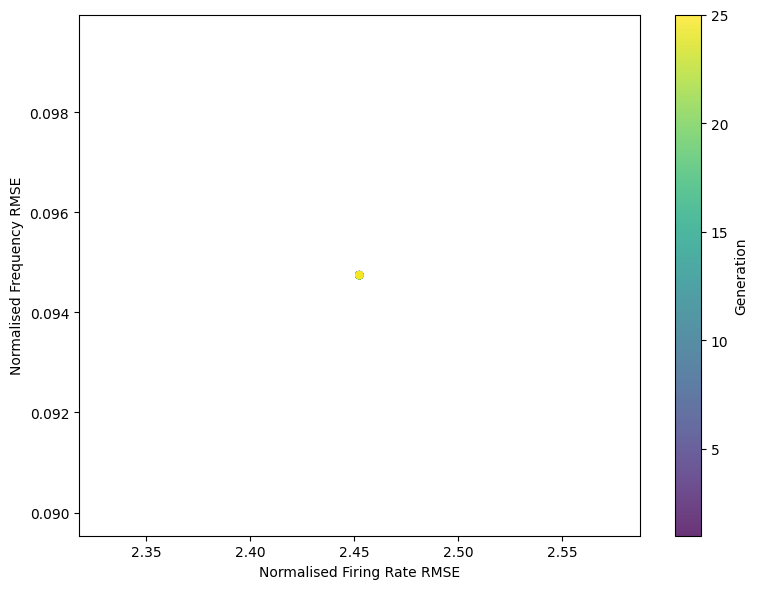

In [2]:
# Load the Pareto frontier CSV for the organoid GA run
# NOTE: update path as per local relative path
df = pd.read_csv("SNN_GA/results/snn_ga_organoid/organoid_20260407-151207/frontier_full.csv")
# Extract normalised RMSE values
x = df["firing_rate_error_norm"]      # normalised firing‑rate RMSE
y = df["psd_peak_error_norm"]         # normalised PSD‑peak RMSE
gens = df["generation"]               # generation index for colour‑coding
# Scatter plot of frontier points
plt.figure(figsize=(8, 6))
plt.scatter(x, y, c=gens, cmap="viridis", s=25, alpha=0.8)
plt.xlabel("Normalised Firing Rate RMSE")
plt.ylabel("Normalised Frequency RMSE")
plt.colorbar(label="Generation") # colourbar shows generation number
plt.tight_layout()
plt.show()


Average_value =  0.14076190476190473


C:\Users\Divse\AppData\Local\Temp\ipykernel_27860\688630734.py:67: UserWarning: No artists with labels found to put in legend.  Note that artists whose label start with an underscore are ignored when legend() is called with no argument.
  plt.legend()


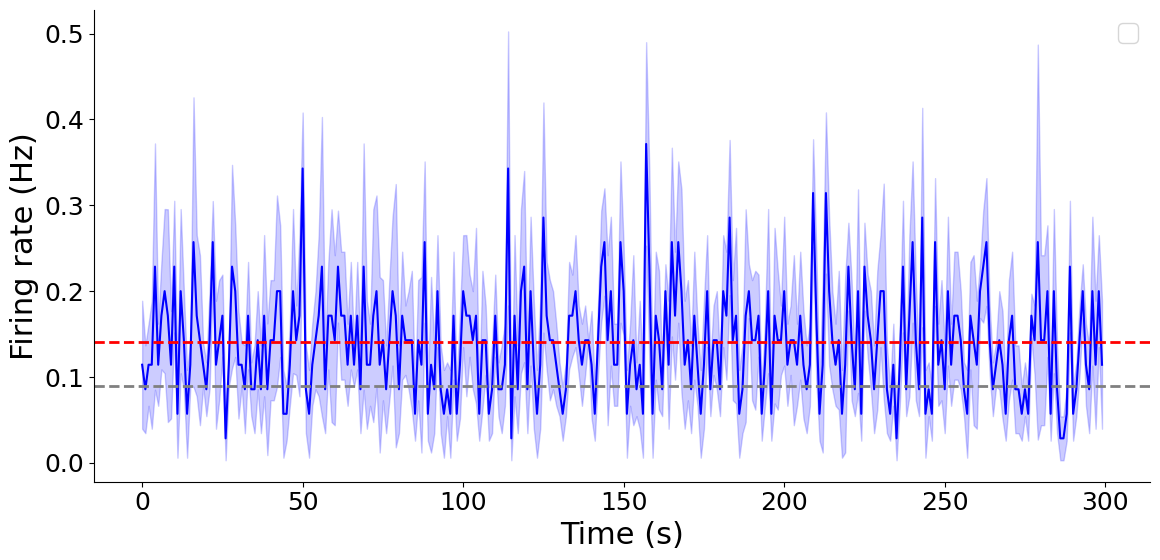

In [ ]:
# Imports for raster‑like spike aggregation and firing‑rate analysis
import numpy as np
import matplotlib.pyplot as plt
import glob
import os
# --- Settings ---
N_neurons = 7 # number of neurons in the organoid model
bin_size = 1000  # 1 second = 1000 ms
# Base directory for this GA run
# NOTE: update path as per local relative path
path = "SNN_GA/results/snn_ga_organoid/organoid_20260407-151207"

# Find all raw trial files for generation 2
trial_files = sorted(glob.glob(os.path.join(path, "gen2_trial*_raw.npz")))

all_rates = []
for f in trial_files:
    raw = np.load(f)
    spikes = raw["spikes_num_fired"]  # spikes per ms (length ~300000)

    # Trim to full 1‑second bins
    num_bins = len(spikes) // bin_size
    spikes = spikes[:num_bins * bin_size]

    # Reshape into (num_seconds × 1000 ms) and sum spikes per second
    spikes_1s = spikes.reshape(num_bins, bin_size).sum(axis=1)

    # Convert to firing rate (Hz per neuron)
    firing_rate_hz = spikes_1s / (1.0 * N_neurons)

    all_rates.append(firing_rate_hz)

# Convert to array: shape (n_trials, n_seconds)
all_rates = np.array(all_rates)

# Compute mean and SEM across trials
mean_rate = all_rates.mean(axis=0)
sem_rate = all_rates.std(axis=0) / np.sqrt(all_rates.shape[0])
# Overall mean firing rate across entire window
overall_mean_blue = mean_rate.mean()
# Time axis in seconds
time_axis = np.arange(mean_rate.shape[0])

# Plot firing rate
plt.figure(figsize=(12, 6))
# High‑quality figure settings
plt.rcParams.update({
    "font.size": 20,
    "axes.titlesize": 22,
    "axes.labelsize": 22,
    "xtick.labelsize": 18,
    "ytick.labelsize": 18,
    "legend.fontsize": 18
})

ax = plt.gca()
ax.spines["top"].set_visible(False)
ax.spines["right"].set_visible(False)
# Mean firing rate curve
plt.plot(time_axis, mean_rate, color="blue")
# SEM shading
plt.fill_between(time_axis, mean_rate - sem_rate, mean_rate + sem_rate,
                 color="blue", alpha=0.2)
# Target firing rate line (0.09 Hz)
plt.axhline(0.09, color="gray", linestyle="--", linewidth=2, label="Target = 0.09 Hz")
# Print and plot the actual mean firing rate
print("Average_value = ", overall_mean_blue) 
plt.axhline(overall_mean_blue, color="red", linestyle="--", linewidth=2, label=f"Rate = {overall_mean_blue:.3f} Hz")

plt.xlabel("Time (s)")
plt.ylabel("Firing rate (Hz)")
plt.legend()
plt.tight_layout()
# Optionally auto-save figure
# plt.savefig("firing_rate_1s_bins_avg.png")
plt.show()


Peak in 0–0.2 Hz window: 0.1534356237491661


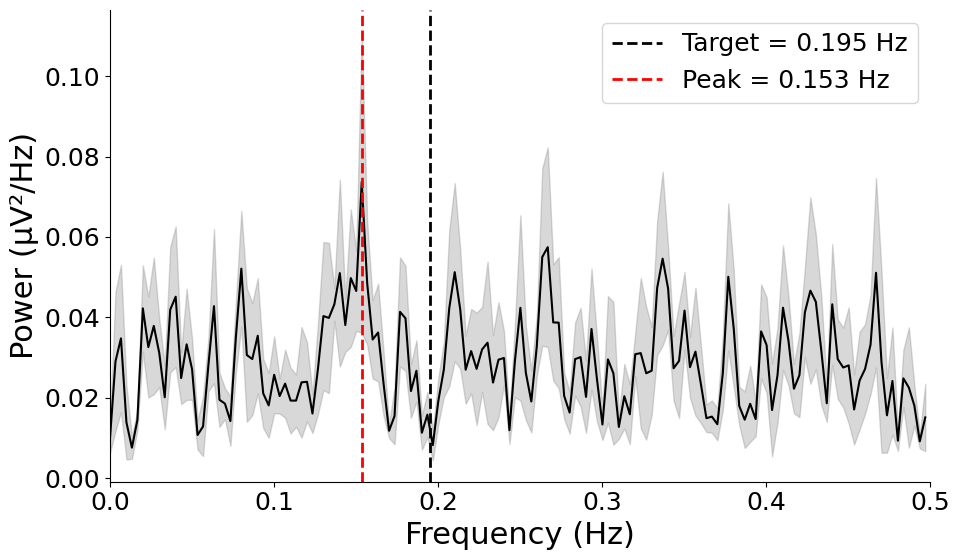

In [ ]:
# PSD analysis for organoid model
import numpy as np
import matplotlib.pyplot as plt
from scipy.signal import find_peaks

# Load averaged PSD for generation 2
# NOTE: update path as per local relative path
data = np.load("SNN_GA/results/snn_ga_organoid/organoid_20260407-151207/avg_psd_gen2.npz")
freq = data["freq"]          # frequency axis
psd_mean = data["psd_mean"]  # mean PSD
psd_sem = data["psd_sem"]    # SEM of PSD

# Select only the 0–0.2 Hz window (organoid oscillation band)
mask = (freq >= 0) & (freq <= 0.2)
freq_window = freq[mask]
psd_window = psd_mean[mask]

# Find the highest PSD peak in this window
peak_idx = np.argmax(psd_window)
peak_freq = freq_window[peak_idx]

print("Peak in 0–0.2 Hz window:", peak_freq)

# Plot PSD with peak annotation
plt.figure(figsize=(10, 6))

# Global font size
plt.rcParams.update({
    "font.size": 20,
    "axes.titlesize": 22,
    "axes.labelsize": 22,
    "xtick.labelsize": 18,
    "ytick.labelsize": 18,
    "legend.fontsize": 18
})

ax = plt.gca()

# Remove top + right spines
ax.spines["top"].set_visible(False)
ax.spines["right"].set_visible(False)
# PSD curve
plt.plot(freq, psd_mean, color="black")
# SEM shading
plt.fill_between(freq, psd_mean - psd_sem, psd_mean + psd_sem,
                 color="gray", alpha=0.3)

# Target frequency line (0.195 Hz)
plt.axvline(0.195, color="black", linestyle="--", linewidth=2,
            label="Target = 0.195 Hz")

# Actual peak frequency (red)
plt.axvline(peak_freq, color="red", linestyle="--", linewidth=2,
            label=f"Peak = {peak_freq:.3f} Hz")

plt.xlim(0, 0.5)
plt.xlabel("Frequency (Hz)")
plt.ylabel("Power (μV²/Hz)")
plt.legend()
plt.tight_layout()
# Optionally auto-save figure
# plt.savefig("organoid_psd_peak.png")
plt.show()